In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive

 17567478684217814787199691655893.jpg
'2. Discuss Data Warehouse modeling..gsheet'
'Aadhaars '
'Byte bounty .pdf'
 Classroom
'Colab Notebooks'
'critical assignment .pdf'
'Document from Tadepalli Tejesh'
 finger_dataset_balanced.zip
 finger_dataset.zip
 finger_fracture_mobilenet_clahe_81acc.keras
 finger_fracture_mobilenet_v2_78acc.keras
 finger_fracture_model.h5
 finger_fracture_model.keras
'Fracture Detection Research Analysis Table.gsheet'
'Google AI Studio'
 important_questions.gdoc
'i want west bengal disrict coordinates of all dis....gsheet'
'mlh (2).pdf'
 MLH.drawio.png
 MURA-v1.1
'NASA Space Apps Challenge.pdf'
'now iam Andhra pradesh Districts of East Godavari....gsheet'
'PROBLEMS_ON_TIME_COMPLEXITY (1).gdoc'
 shortMemo.pdf
'SSEPM Research Paper.gdoc'
'Tadepalli Venkata Sivarama Tejesh  Certificate.pdf'
'Tejesh tadepalli - 1 (1).pdf'
'Tejesh tadepalli - 1.pdf'
'then give me individual coordinates of each distr....gsheet'
'Untitled document (1).gdoc'
'Untitled document.gdoc'
'Un

In [ ]:
!unzip -o "/content/drive/MyDrive/finger_dataset.zip" -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/content/finger_dataset/train/fractured/patient03545_study1_positive_image2.png  
  inflating: /content/content/finger_dataset/train/fractured/patient03543_study1_positive_image2.png  
  inflating: /content/content/finger_dataset/train/fractured/patient03755_study1_positive_image2.png  
  inflating: /content/content/finger_dataset/train/fractured/patient00440_study1_positive_image1.png  
  inflating: /content/content/finger_dataset/train/fractured/patient03257_study1_positive_image1.png  
 extracting: /content/content/finger_dataset/train/fractured/patient03497_study1_positive_image1.png  
 extracting: /content/content/finger_dataset/train/fractured/patient03796_study1_positive_image3.png  
  inflating: /content/content/finger_dataset/train/fractured/patient03389_study1_positive_image1.png  
 extracting: /content/content/finger_dataset/train/fractured/patient03663_study1_positive_image1.png  
 extracting: /content/

In [ ]:
!ls /content/content/finger_dataset/train

fractured  normal


In [ ]:
!mv /content/content/finger_dataset /content/

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = "/content/finger_dataset/train"
test_dir = "/content/finger_dataset/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1./255)

print("Setting up Training Generator...")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("\nSetting up Testing Generator...")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False

Setting up Training Generator...
Found 5106 images belonging to 2 classes.

Setting up Testing Generator...
Found 461 images belonging to 2 classes.


In [ ]:
import numpy as np
from sklearn.utils import class_weight

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
train_class_weights = dict(enumerate(weights))

print("\nClass Weights calculated:")
print(f"Class 0 (Fractured): {train_class_weights[0]:.4f}")
print(f"Class 1 (Normal): {train_class_weights[1]:.4f}")


Class Weights calculated:
Class 0 (Fractured): 1.2973
Class 1 (Normal): 0.8136


#Base Model

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False


model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Phase 1 Model built and compiled successfully!")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Phase 1 Model built and compiled successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
print("Starting Phase 1: Warm-up Training...")

history_warmup = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=5,
    class_weight=train_class_weights
)

print("Phase 1 complete!")

Starting Phase 1: Warm-up Training...
Epoch 1/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 136s 723ms/step - accuracy: 0.6110 - loss: 0.6646 - val_accuracy: 0.6920 - val_loss: 0.6034
Epoch 2/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 86s 540ms/step - accuracy: 0.6643 - loss: 0.6025 - val_accuracy: 0.6855 - val_loss: 0.6036
Epoch 3/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 86s 536ms/step - accuracy: 0.6743 - loss: 0.5903 - val_accuracy: 0.6963 - val_loss: 0.6032
Epoch 4/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 86s 535ms/step - accuracy: 0.6849 - loss: 0.5689 - val_accuracy: 0.6876 - val_loss: 0.6017
Epoch 5/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 85s 534ms/step - accuracy: 0.6876 - loss: 0.5638 - val_accuracy: 0.6876 - val_loss: 0.5950
Phase 1 complete!


In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

print("Starting Phase 2: Fine-Tuning...")
history_finetune = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=15,
    class_weight=train_class_weights,
    callbacks=[early_stop]
)

print("Phase 2 complete! Best weights locked in.")

Starting Phase 2: Fine-Tuning...
Epoch 1/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 130s 661ms/step - accuracy: 0.6680 - loss: 0.6182 - val_accuracy: 0.6876 - val_loss: 0.6001
Epoch 2/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 86s 539ms/step - accuracy: 0.6827 - loss: 0.5886 - val_accuracy: 0.6833 - val_loss: 0.6032
Epoch 3/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 86s 536ms/step - accuracy: 0.6970 - loss: 0.5604 - val_accuracy: 0.6855 - val_loss: 0.5850
Epoch 4/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 86s 535ms/step - accuracy: 0.7070 - loss: 0.5479 - val_accuracy: 0.6985 - val_loss: 0.5780
Epoch 5/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 86s 537ms/step - accuracy: 0.7311 - loss: 0.5237 - val_accuracy: 0.7028 - val_loss: 0.5672
Epoch 6/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 86s 537ms/step - accuracy: 0.7313 - loss: 0.5291 - val_accuracy: 0.6985 - val_loss: 0.5636
Epoch 7/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 86s 535ms/step - accuracy: 0.7354 - loss: 0.5138 - val_accuracy: 0.7072 - val_loss: 0.5566
Epoch 8/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 85s 531ms

Evaluating model on test data...
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 502ms/step

Confusion Matrix:
[[195  52]
 [ 68 146]]

Classification Report:
               precision    recall  f1-score   support

Fractured (0)       0.74      0.79      0.76       247
   Normal (1)       0.74      0.68      0.71       214

     accuracy                           0.74       461
    macro avg       0.74      0.74      0.74       461
 weighted avg       0.74      0.74      0.74       461



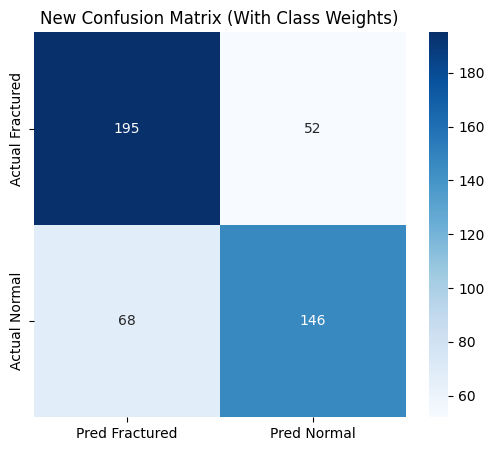

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("Evaluating model on test data...")

Y_pred = model.predict(test_generator)
y_pred = (Y_pred > 0.5).astype(int)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Fractured (0)', 'Normal (1)']))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Fractured', 'Pred Normal'],
            yticklabels=['Actual Fractured', 'Actual Normal'])
plt.title('New Confusion Matrix (With Class Weights)')
plt.show()

In [ ]:
model_save_path = "/content/drive/MyDrive/finger_fracture_mobilenet_v2_78acc.keras"
model.save(model_save_path)

print(f"Model successfully saved to: {model_save_path}")

Model successfully saved to: /content/drive/MyDrive/finger_fracture_mobilenet_v2_78acc.keras


#New Strategie
1. CLAHE
2. Increasing resolution to 336, 336

In [ ]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Bump up the resolution!
IMG_SIZE = (336, 336)
BATCH_SIZE = 32

train_dir = "/content/finger_dataset/train"
test_dir = "/content/finger_dataset/test"

def apply_clahe(img):

    img_uint8 = np.uint8(img)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    clahe_img = clahe.apply(gray)

    clahe_rgb = cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2RGB)

    return clahe_rgb.astype('float32')

print("Setting up Enhanced Training Generator...")

train_datagen = ImageDataGenerator(
    preprocessing_function=apply_clahe,
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True
)


test_datagen = ImageDataGenerator(
    preprocessing_function=apply_clahe,
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("\nSetting up Enhanced Testing Generator...")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\nData loaded with high resolution and CLAHE enhancement!")

Setting up Enhanced Training Generator...
Found 5106 images belonging to 2 classes.

Setting up Enhanced Testing Generator...
Found 461 images belonging to 2 classes.

Data loaded with high resolution and CLAHE enhancement!


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(
    input_shape=(336, 336, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Phase 1 Model built and compiled successfully!")
model.summary()

/tmp/ipykernel_1361/2090915500.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Phase 1 Model built and compiled successfully!


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 11, 11, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
print("Starting Phase 1: Warm-up Training...")

history_warmup = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=5,
    class_weight=train_class_weights
)

print("Phase 1 complete!")

Starting Phase 1: Warm-up Training...
Epoch 1/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - accuracy: 0.6214 - loss: 0.6485 - val_accuracy: 0.6811 - val_loss: 0.5927
Epoch 2/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.6665 - loss: 0.6027 - val_accuracy: 0.7202 - val_loss: 0.5799
Epoch 3/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.6823 - loss: 0.5815 - val_accuracy: 0.6985 - val_loss: 0.5758
Epoch 4/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.6958 - loss: 0.5656 - val_accuracy: 0.7050 - val_loss: 0.5679
Epoch 5/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.7025 - loss: 0.5564 - val_accuracy: 0.7137 - val_loss: 0.5817
Phase 1 complete!


In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

print("Starting Phase 2: High-Resolution Fine-Tuning...")

history_finetune = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=15,
    class_weight=train_class_weights,
    callbacks=[early_stop]
)

print("Phase 2 complete! Best weights locked in.")

Starting Phase 2: High-Resolution Fine-Tuning...
Epoch 1/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.6792 - loss: 0.5998 - val_accuracy: 0.6833 - val_loss: 0.6267
Epoch 2/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.7066 - loss: 0.5610 - val_accuracy: 0.6963 - val_loss: 0.6194
Epoch 3/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.7170 - loss: 0.5349 - val_accuracy: 0.7267 - val_loss: 0.5934
Epoch 4/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.7370 - loss: 0.5179 - val_accuracy: 0.7419 - val_loss: 0.5768
Epoch 5/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.7507 - loss: 0.5060 - val_accuracy: 0.7354 - val_loss: 0.5478
Epoch 6/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.7617 - loss: 0.4910 - val_accuracy: 0.7375 - val_loss: 0.5376
Epoch 7/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.7673 - loss: 0.4805 - val_accuracy: 0.7354 - val_loss: 0.5369
Epoch 8/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/

Evaluating Enhanced Model on test data...
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 606ms/step

Confusion Matrix:
[[198  49]
 [ 60 154]]

Classification Report:
               precision    recall  f1-score   support

Fractured (0)       0.77      0.80      0.78       247
   Normal (1)       0.76      0.72      0.74       214

     accuracy                           0.76       461
    macro avg       0.76      0.76      0.76       461
 weighted avg       0.76      0.76      0.76       461



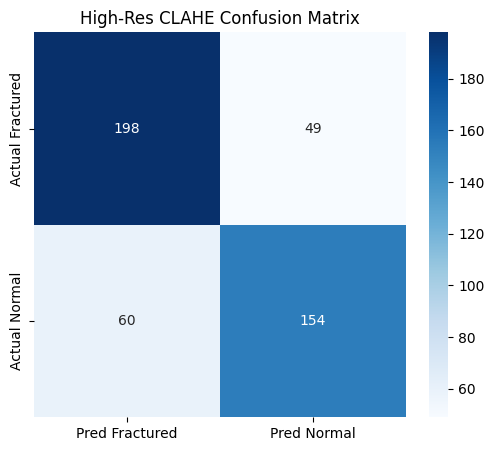

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("Evaluating Enhanced Model on test data...")
Y_pred = model.predict(test_generator)
y_pred = (Y_pred > 0.5).astype(int)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)


print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Fractured (0)', 'Normal (1)']))


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Fractured', 'Pred Normal'],
            yticklabels=['Actual Fractured', 'Actual Normal'])
plt.title('High-Res CLAHE Confusion Matrix')
plt.show()

In [ ]:

enhanced_model_path = "/content/drive/MyDrive/finger_fracture_mobilenet_clahe_81acc.keras"
model.save(enhanced_model_path)

print(f"Bujji saved your super-model to: {enhanced_model_path}")

Bujji saved your super-model to: /content/drive/MyDrive/finger_fracture_mobilenet_clahe_81acc.keras


#For DenseNet

In [ ]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight

IMG_SIZE = (336, 336)
BATCH_SIZE = 32

# The CLAHE function
def apply_clahe(img):
    img_uint8 = np.uint8(img)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    clahe_img = clahe.apply(gray)
    clahe_rgb = cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2RGB)
    return clahe_rgb.astype('float32')

# Set up generators
train_datagen = ImageDataGenerator(
    preprocessing_function=apply_clahe,
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    preprocessing_function=apply_clahe,
    rescale=1./255
)

print("Loading data...")
train_generator = train_datagen.flow_from_directory(
    "/content/finger_dataset/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    "/content/finger_dataset/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Recalculate weights
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
train_class_weights = dict(enumerate(weights))
print("\nGenerators and Class Weights are fully restored and ready!")

Loading data...
Found 5106 images belonging to 2 classes.
Found 461 images belonging to 2 classes.

Generators and Class Weights are fully restored and ready!


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

base_model_dense = DenseNet121(
    input_shape=(336, 336, 3),
    include_top=False,
    weights='imagenet'
)


base_model_dense.trainable = False


model_dense = models.Sequential([
    base_model_dense,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_dense.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Starting DenseNet Phase 1: Warm-up Training...")
history_dense_warmup = model_dense.fit(
    train_generator,
    validation_data=test_generator,
    epochs=5,
    class_weight=train_class_weights
)
print("Phase 1 complete!")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting DenseNet Phase 1: Warm-up Training...
Epoch 1/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.6154 - loss: 0.6646 - val_accuracy: 0.7028 - val_loss: 0.5981
Epoch 2/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.6725 - loss: 0.6033 - val_accuracy: 0.7375 - val_loss: 0.5612
Epoch 3/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.6774 - loss: 0.5900 - val_accuracy: 0.7202 - val_loss: 0.5565
Epoch 4/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.6915 - loss: 0.5706 - val_accuracy: 0.7419 - val_loss: 0.5506
Epoch 5/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.6984 - loss: 0.5642 - val_accuracy: 0.7419 - val_loss: 0.5463
Phase 1 complete!


In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

base_model_dense.trainable = True
for layer in base_model_dense.layers[:-50]:
    layer.trainable = False
model_dense.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7
)

print("Starting DenseNet Phase 2: High-Resolution Fine-Tuning...")


history_dense_finetune = model_dense.fit(
    train_generator,
    validation_data=test_generator,
    epochs=15,
    class_weight=train_class_weights,
    callbacks=[early_stop, lr_scheduler]
)

print("DenseNet Phase 2 complete! Best weights locked in.")

Starting DenseNet Phase 2: High-Resolution Fine-Tuning...
Epoch 1/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.6698 - loss: 0.6014 - val_accuracy: 0.7462 - val_loss: 0.5390 - learning_rate: 1.0000e-05
Epoch 2/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.6782 - loss: 0.5845 - val_accuracy: 0.7549 - val_loss: 0.5323 - learning_rate: 1.0000e-05
Epoch 3/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.6929 - loss: 0.5699 - val_accuracy: 0.7505 - val_loss: 0.5283 - learning_rate: 1.0000e-05
Epoch 4/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.7094 - loss: 0.5511 - val_accuracy: 0.7570 - val_loss: 0.5255 - learning_rate: 1.0000e-05
Epoch 5/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.7096 - loss: 0.5473 - val_accuracy: 0.7592 - val_loss: 0.5222 - learning_rate: 1.0000e-05
Epoch 6/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.7098 - loss: 0.5506 - val_accuracy: 0.7592 - val_loss: 0.5201 - learning_rate: 1.0000e-05


Evaluating DenseNet121 Super-Model on test data...
15/15 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step

DenseNet Confusion Matrix:
[[186  61]
 [ 47 167]]

DenseNet Classification Report:
               precision    recall  f1-score   support

Fractured (0)       0.80      0.75      0.78       247
   Normal (1)       0.73      0.78      0.76       214

     accuracy                           0.77       461
    macro avg       0.77      0.77      0.77       461
 weighted avg       0.77      0.77      0.77       461



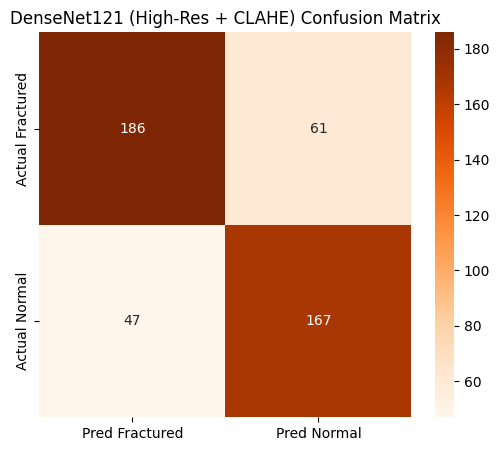

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("Evaluating DenseNet121 Super-Model on test data...")

Y_pred_dense = model_dense.predict(test_generator)
y_pred_dense = (Y_pred_dense > 0.5).astype(int)
y_true = test_generator.classes

cm_dense = confusion_matrix(y_true, y_pred_dense)
print("\nDenseNet Confusion Matrix:")
print(cm_dense)

print("\nDenseNet Classification Report:")
print(classification_report(y_true, y_pred_dense, target_names=['Fractured (0)', 'Normal (1)']))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_dense, annot=True, fmt='d', cmap='Oranges', # Let's use orange to tell it apart!
            xticklabels=['Pred Fractured', 'Pred Normal'],
            yticklabels=['Actual Fractured', 'Actual Normal'])
plt.title('DenseNet121 (High-Res + CLAHE) Confusion Matrix')
plt.show()

#**Load the MobileNet Model**

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from google.colab import drive

def apply_clahe(img):
    img_uint8 = np.uint8(img)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    clahe_img = clahe.apply(gray)
    clahe_rgb = cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2RGB)
    return clahe_rgb.astype('float32')

# 3. Load the Winning Super-Model
from tensorflow.keras.models import load_model
model = load_model("/content/drive/MyDrive/finger_fracture_mobilenet_clahe_81acc.keras")

#Grad CAM Implementation

In [ ]:
def analyze_xray(img_path, ground_truth_label):
    img = image.load_img(img_path, target_size=(336, 336))
    img_array_raw = image.img_to_array(img)

    # Apply CLAHE and Rescale (MUST match training data)
    img_array = apply_clahe(img_array_raw)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)


    raw_prediction = model.predict(img_array)[0][0] # Probability of Class 1 (Normal)
    prob_fracture = 1.0 - raw_prediction            # Probability of Class 0 (Fractured)

    if prob_fracture > 0.5:
        pred_label = "Fractured"
    else:
        pred_label = "Normal"

    if prob_fracture >= 0.70:
        triage = "HIGH RISK - Immediate Review"
    elif prob_fracture >= 0.40:
        triage = "MEDIUM RISK - Secondary Check"
    else:
        triage = "LOW RISK - Likely Normal"


    base_model = model.layers[0]
    last_conv_layer = base_model.get_layer("Conv_1")

    x = base_model.output
    for layer in model.layers[1:]:
        x = layer(x)

    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[last_conv_layer.output, x]
    )


    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = 1.0 - predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)

    if tf.reduce_max(heatmap) != 0:
        heatmap /= tf.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    background = cv2.cvtColor(img_array[0], cv2.COLOR_RGB2BGR)
    background = np.uint8(255 * background)

    heatmap_resized = cv2.resize(heatmap, (336, 336))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

    overlay = heatmap_color * 0.4 + background
    overlay_rgb = cv2.cvtColor(overlay.astype('uint8'), cv2.COLOR_BGR2RGB)

    # --- 7. DISPLAY FINAL REPORT ---
    plt.figure(figsize=(12, 6))


    plt.subplot(1, 2, 1)
    plt.imshow(img_array[0])
    plt.title(f"Original X-Ray (CLAHE Enhanced)\nActual: {ground_truth_label}")
    plt.axis('off')


    plt.subplot(1, 2, 2)
    plt.imshow(overlay_rgb)
    plt.title(f"Grad-CAM Explainability\nPrediction: {pred_label} (Conf: {prob_fracture*100:.1f}%)")
    plt.axis('off')

    plt.suptitle(f"CLINICAL TRIAGE: {triage}", fontsize=16, fontweight='bold', color='darkred' if prob_fracture >= 0.7 else 'darkorange' if prob_fracture >= 0.4 else 'darkgreen')
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step


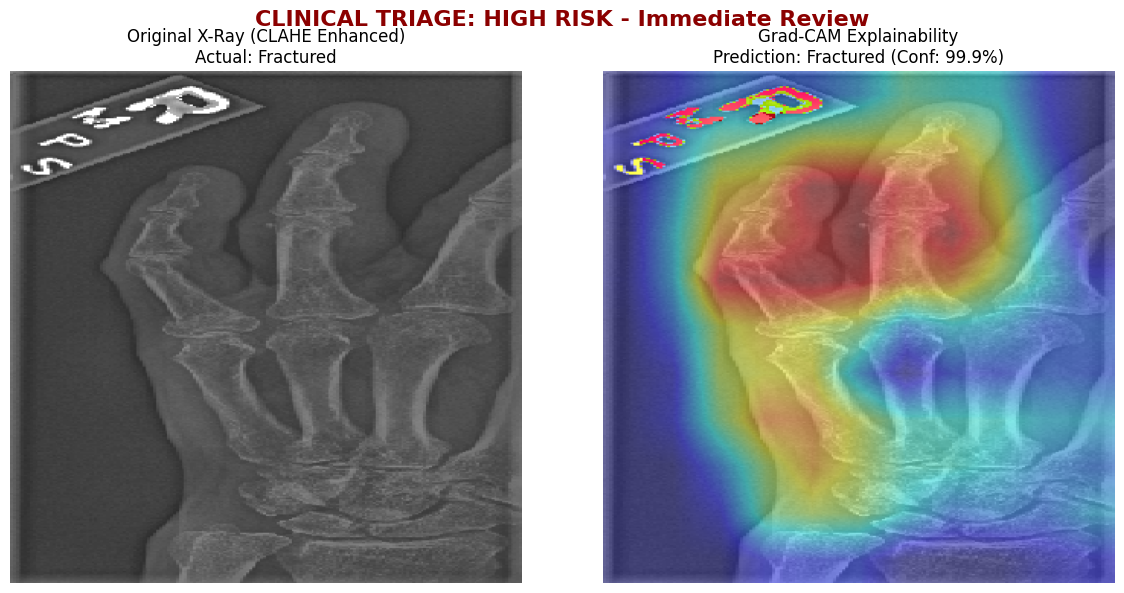

In [ ]:

test_image_path = "/content/finger_dataset/test/fractured/patient11383_study1_positive_image3.png" # Update this path if needed
analyze_xray(test_image_path, "Fractured")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


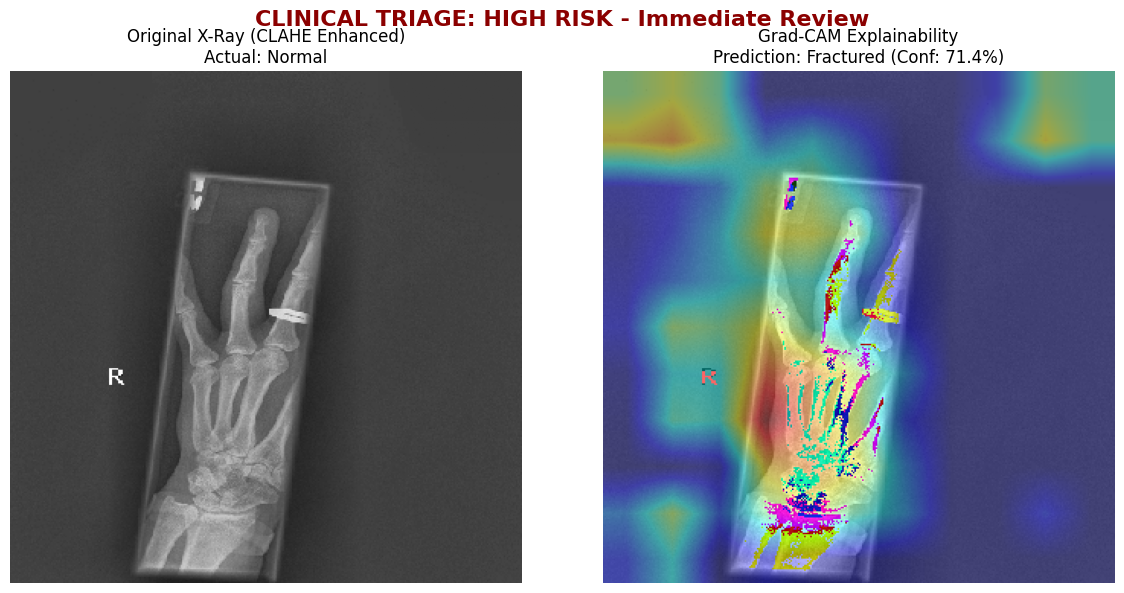

In [ ]:
# Test it with an image!
test_image_path = "/content/finger_dataset/test/normal/patient11937_study1_negative_image3.png" # Update this path if needed
analyze_xray(test_image_path, "Normal")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


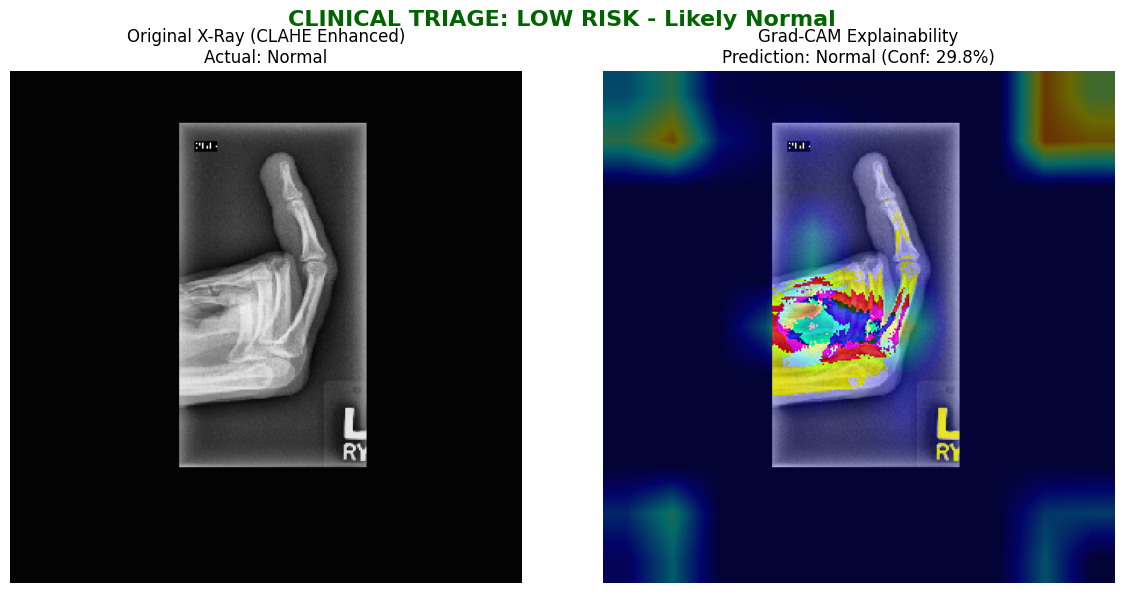

In [ ]:
# Test it with an image!
test_image_path = "/content/finger_dataset/test/normal/patient11967_study1_negative_image4.png" # Update this path if needed
analyze_xray(test_image_path, "Normal")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


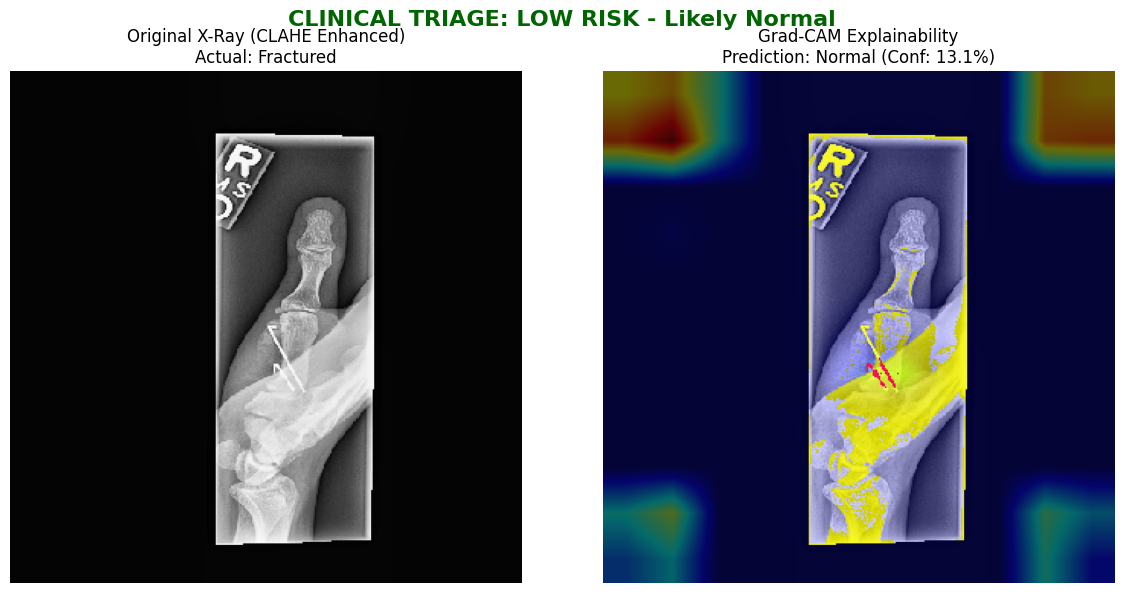

In [ ]:
# Test it with an image!
test_image_path = "/content/finger_dataset/test/fractured/patient11920_study1_positive_image3.png" # Update this path if needed
analyze_xray(test_image_path, "Fractured")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


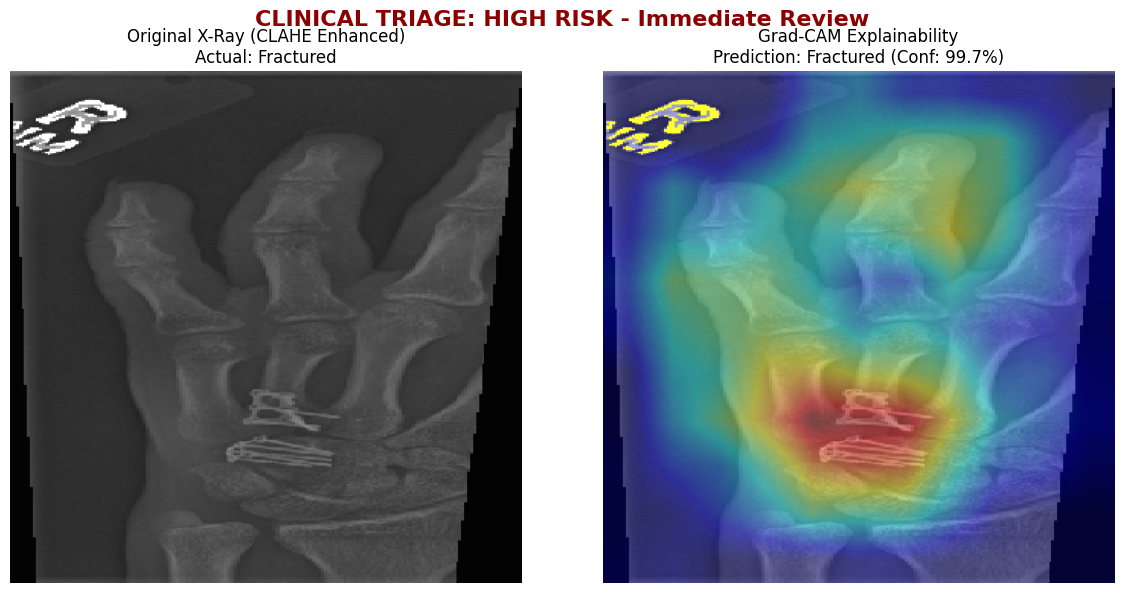

In [ ]:
# Test it with an image!
test_image_path = "/content/finger_dataset/test/fractured/patient11723_study1_positive_image2.png" # Update this path if needed
analyze_xray(test_image_path, "Fractured")

Generating comparison image...


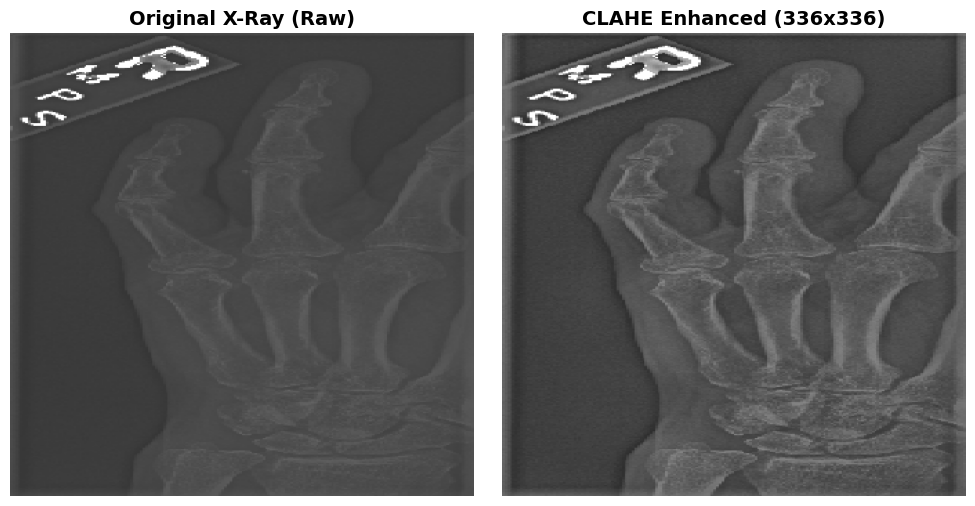

✅ Success! High-resolution image saved to: /content/preprocessing_comparison.png
You can now download 'preprocessing_comparison.png' from your Colab files menu!


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# 1. The exact CLAHE function from your pipeline
def apply_clahe(img):
    img_uint8 = np.uint8(img)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    clahe_img = clahe.apply(gray)
    clahe_rgb = cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2RGB)
    return clahe_rgb.astype('float32')

# 2. PASTE THE PATH TO A RAW IMAGE HERE
# (Pick one that is dark or blurry to show off your enhancement!)
sample_image_path = "/content/finger_dataset/test/fractured/patient11383_study1_positive_image3.png"

print("Generating comparison image...")

# 3. Load the raw image
img = image.load_img(sample_image_path, target_size=(336, 336))
img_array_raw = image.img_to_array(img)

# 4. Apply your magic CLAHE enhancement
img_array_enhanced = apply_clahe(img_array_raw)

# 5. Plot them beautifully side-by-side
plt.figure(figsize=(10, 5))

# Left: Original
plt.subplot(1, 2, 1)
plt.imshow(np.uint8(img_array_raw))
plt.title("Original X-Ray (Raw)", fontsize=14, fontweight='bold')
plt.axis('off')

# Right: Enhanced
plt.subplot(1, 2, 2)
plt.imshow(np.uint8(img_array_enhanced))
plt.title("CLAHE Enhanced (336x336)", fontsize=14, fontweight='bold')
plt.axis('off')

plt.tight_layout()

# 6. Save it at 300 DPI (High Resolution for Research Papers!)
save_path = "/content/preprocessing_comparison.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Success! High-resolution image saved to: {save_path}")
print("You can now download 'preprocessing_comparison.png' from your Colab files menu!")